In [1]:
#standard imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data = pd.read_csv("D:\CodeAlpha\Car-Price-Prediction-task2\car data.csv")

### 1- Explore Data

In [3]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
data.shape

(301, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
data.duplicated().sum()

2

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.shape

(299, 9)

In [10]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### 2- Analysis

In [11]:
 data['Car_Name'].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [12]:
for col in data.columns:
    print(col,":",data[col].nunique())

Car_Name : 98
Year : 16
Selling_Price : 156
Present_Price : 148
Driven_kms : 206
Fuel_Type : 3
Selling_type : 2
Transmission : 2
Owner : 3


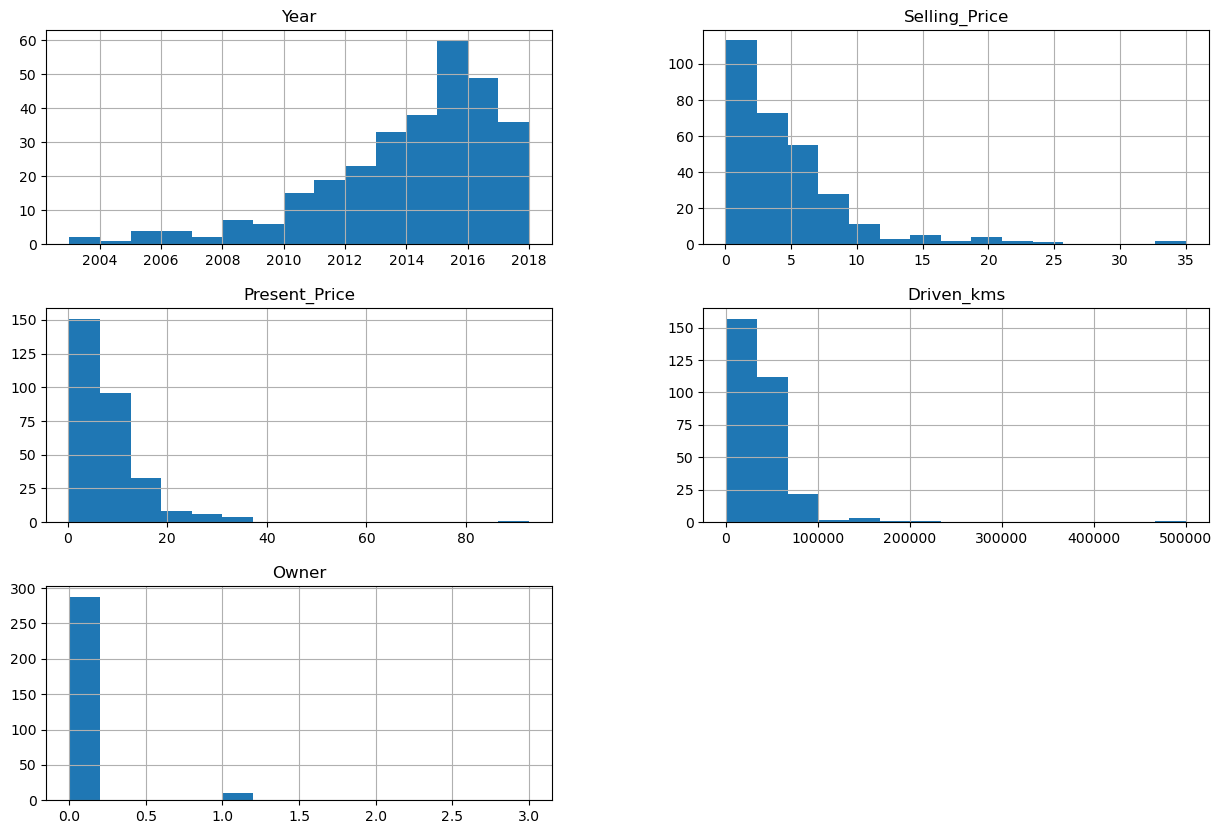

In [13]:
data.hist(bins=15,figsize=(15,10))
plt.show()

In [14]:
top10cars = data['Car_Name'].value_counts().sort_values(ascending=False)[:10]
top10cars

Car_Name
city                         26
corolla altis                16
verna                        14
brio                         10
fortuner                     10
ciaz                          9
innova                        9
i20                           9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64

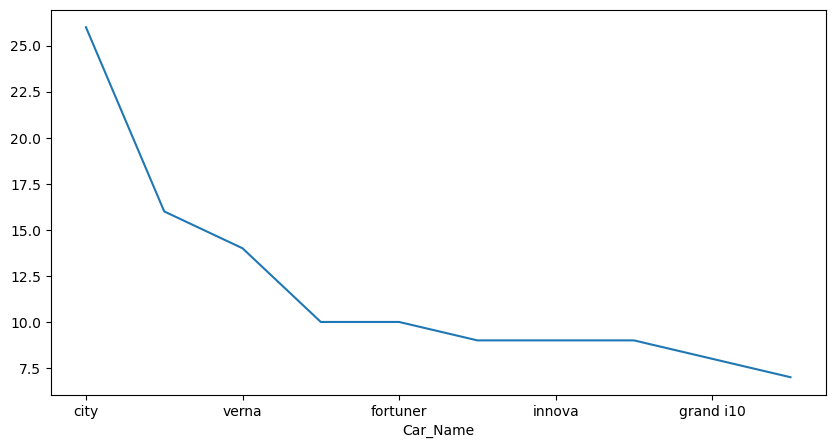

In [15]:
top10cars.plot(figsize=(10,5))
plt.show()

In [16]:
top10meanPresent_Prices = [data[data['Car_Name']==i]['Present_Price'].mean() for i in list(top10cars.index)]

In [17]:
top10meanPresent_Prices

[11.791923076923078,
 17.5825,
 9.328571428571431,
 6.044,
 30.744999999999997,
 9.756666666666668,
 17.846666666666668,
 7.205555555555555,
 5.7,
 1.4700000000000002]

In [18]:
top10meanSelling_Prices = [data[data['Car_Name']==i]['Selling_Price'].mean() for i in list(top10cars.index)]

In [19]:
top10meanSelling_Prices

[7.4192307692307695,
 7.1831249999999995,
 6.107857142857143,
 4.745,
 18.253999999999998,
 7.472222222222222,
 12.777777777777779,
 4.7666666666666675,
 4.94375,
 1.1442857142857144]

In [20]:
data.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000


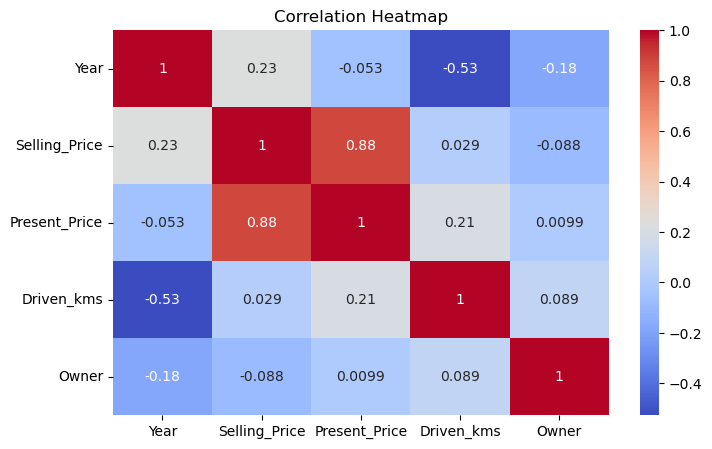

In [21]:
numeric_cols = ["Year", "Selling_Price", "Present_Price", "Driven_kms", "Owner"]

plt.figure(figsize=(8, 5))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

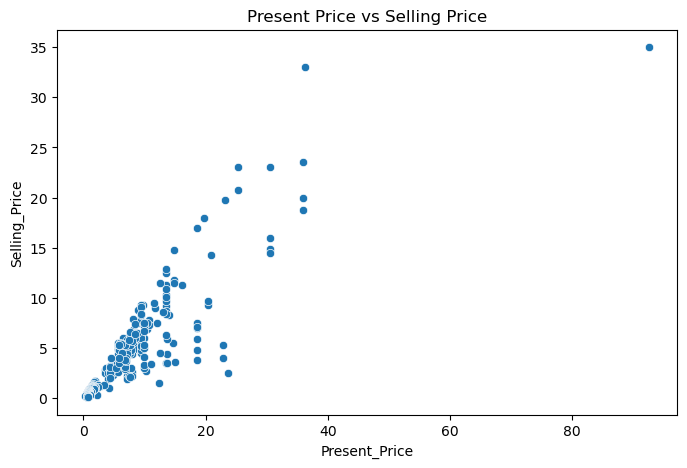

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Present_Price", y="Selling_Price", data=data)
plt.title("Present Price vs Selling Price")
plt.show()
#if current price of the car increases, the selling price usually increases as well.

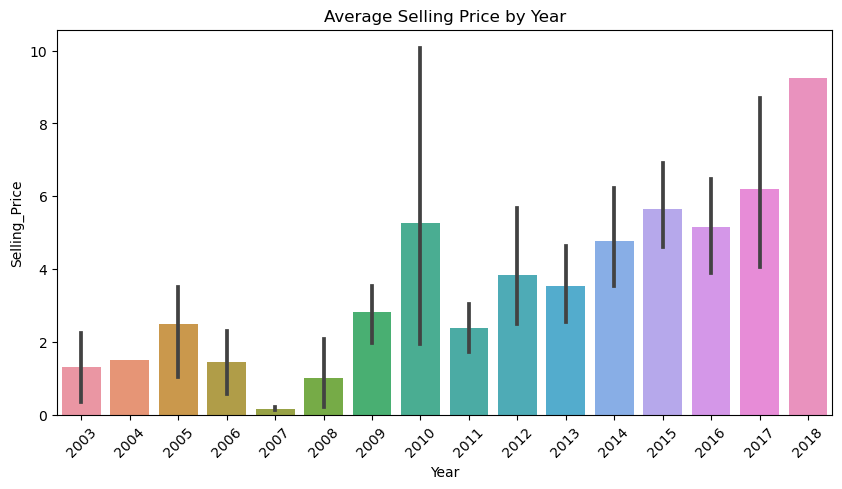

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(x="Year", y="Selling_Price", data=data, estimator="mean")
plt.xticks(rotation=45)
plt.title("Average Selling Price by Year")
plt.show()
#so, newer cars are often more expensive.

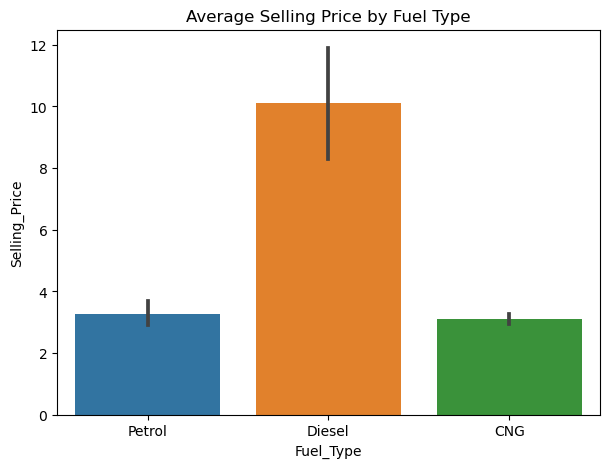

In [24]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Fuel_Type", y="Selling_Price", data=data, estimator="mean")
plt.title("Average Selling Price by Fuel Type")
plt.show()

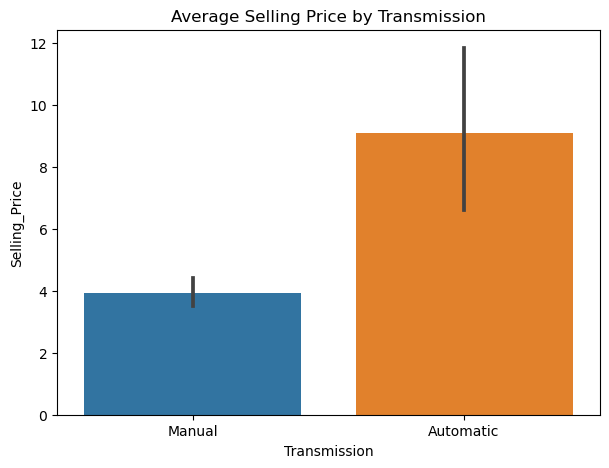

In [25]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Transmission", y="Selling_Price", data=data, estimator="mean")
plt.title("Average Selling Price by Transmission")
plt.show()

In [26]:
data_object = data.select_dtypes(include='object')

In [27]:
data_object.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Car_Name      299 non-null    object
 1   Fuel_Type     299 non-null    object
 2   Selling_type  299 non-null    object
 3   Transmission  299 non-null    object
dtypes: object(4)
memory usage: 11.7+ KB


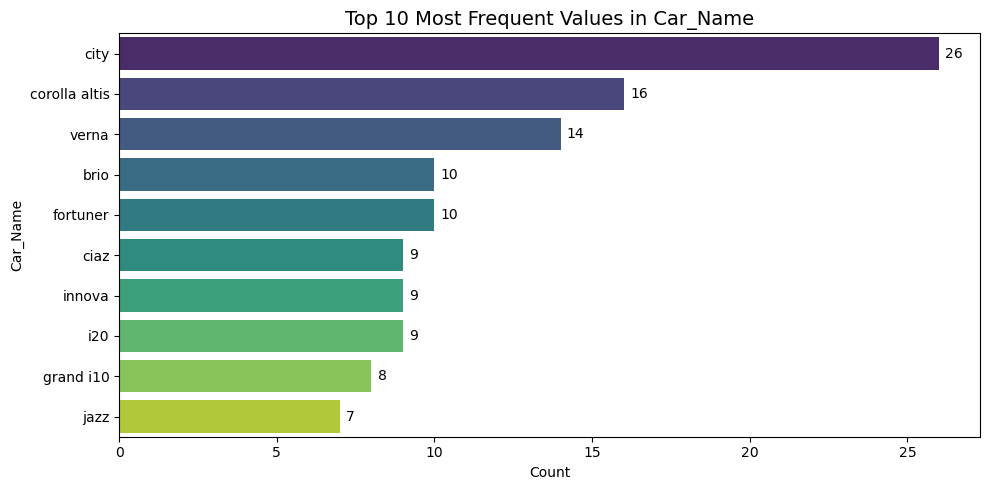

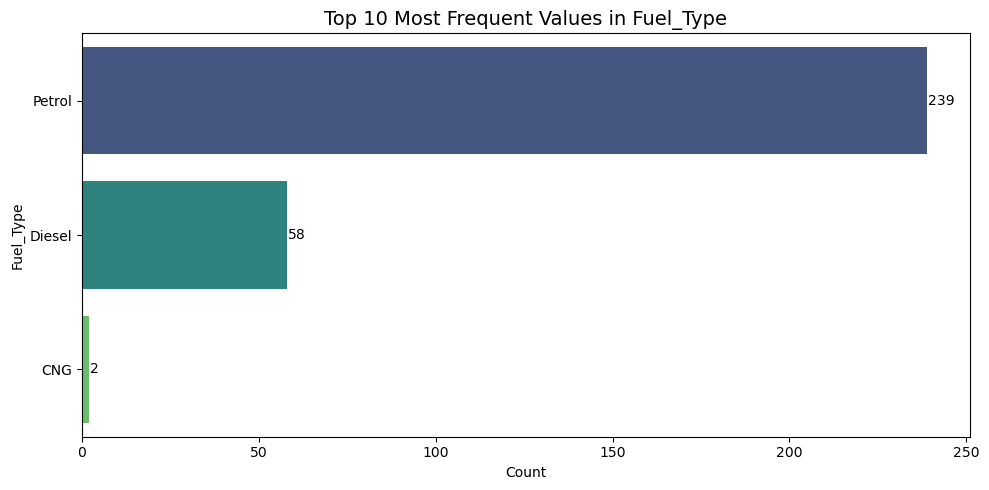

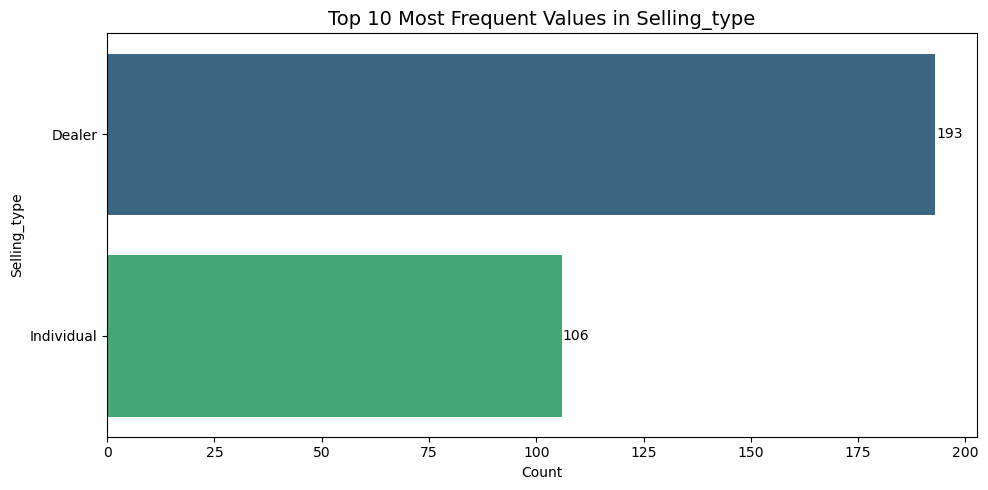

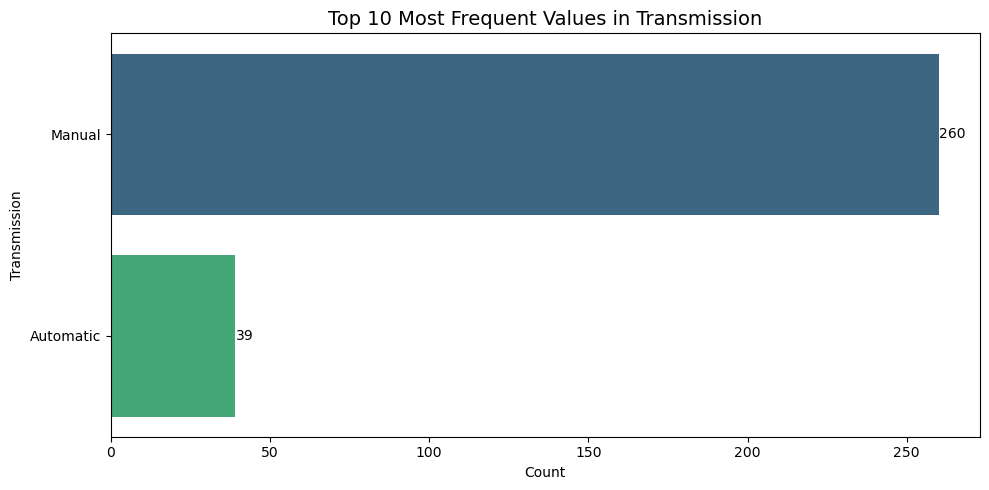

In [28]:
for col in data_object:
    plt.figure(figsize=(10, 5))
    
    top10 = data[col].value_counts().head(10)
    
    ax = sns.barplot(x=top10.values, y=top10.index, palette="viridis")
    
    for i, value in enumerate(top10.values):
        ax.text(value + 0.2, i, str(value), va="center")
    
    plt.title(f"Top 10 Most Frequent Values in {col}", fontsize=14)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 3- Data Processing 

In [29]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Date

In [30]:
import datetime
dtime = datetime.datetime.now()

In [31]:
data['Age'] = dtime.year-data['Year']
#we don't need Year col any more

In [32]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


### Detect Outlier
Outliers were checked in price-related columns because extreme car prices can influence regression models. However, they were not removed automatically because expensive cars may represent valid real-world observations.

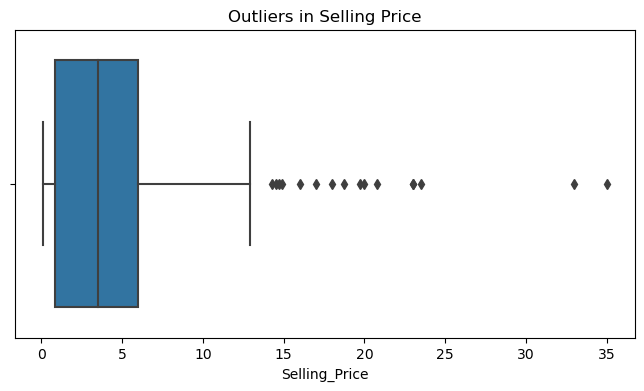

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Selling_Price"])
plt.title("Outliers in Selling Price")
plt.show()

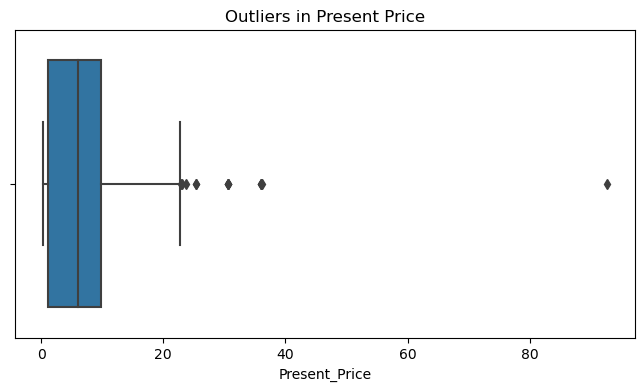

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["Present_Price"])
plt.title("Outliers in Present Price")
plt.show()

In [35]:
Q1 = data["Selling_Price"].quantile(0.25)
Q3 = data["Selling_Price"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = data[(data["Selling_Price"] < lower_limit) | (data["Selling_Price"] > upper_limit)]
outliers

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0,14
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0,11
52,innova,2017,18.00,19.77,15000,Diesel,Dealer,Automatic,0,9
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0,13
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0,12
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0,12
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0,11
64,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0,9
66,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0,9
69,corolla altis,2016,14.25,20.91,12000,Petrol,Dealer,Manual,0,10


 ### Transform Data

In [36]:
dobject = data.select_dtypes(include='object')
dnumeric = data.select_dtypes(exclude='object')

In [37]:
from sklearn.preprocessing import LabelEncoder
la = LabelEncoder()

In [38]:
for i in range(0,dobject.shape[1]):
    dobject.iloc[:,i] = la.fit_transform(dobject.iloc[:,i])

In [39]:
data = pd.concat([dobject,dnumeric],axis=1)

### 4- Model 

In [40]:
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) 

In [42]:
#Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [43]:
#predict linear regression
linear_pred = linear_model.predict(X_test)

In [44]:
#evaluate linear regression

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)


print("Linear Regression Results")
print(f"MAE: {linear_mae:.2f}")
print(f"MSE: {linear_mse:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R2 Score: {linear_r2:.2f}")

Linear Regression Results
MAE: 1.57
MSE: 6.83
RMSE: 2.61
R2 Score: 0.73


In [45]:
# Train Random Forest

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [46]:
rf_pred = rf_model.predict(X_test)

In [47]:
#Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Results")
print(f"MAE: {rf_mae:.2f}")
print(f"MSE: {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2 Score: {rf_r2:.2f}")

Random Forest Regressor Results
MAE: 1.30
MSE: 10.34
RMSE: 3.22
R2 Score: 0.60


In [48]:
#DecisionTreeRegressor model

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor Results")
print(f"MAE: {dt_mae:.2f}")
print(f"MSE: {dt_mse:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R2 Score: {dt_r2:.2f}")

Decision Tree Regressor Results
MAE: 1.07
MSE: 4.13
RMSE: 2.03
R2 Score: 0.84


In [49]:
# Gradient Boosting model

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor Results")
print(f"MAE: {gb_mae:.2f}")
print(f"MSE: {gb_mse:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"R2 Score: {gb_r2:.2f}")

Gradient Boosting Regressor Results
MAE: 1.22
MSE: 7.54
RMSE: 2.75
R2 Score: 0.71


In [50]:
final_model = dt_model
final_predictions = dt_pred

In [51]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Decision Tree", "Gradient Boosting"],
    "MAE": [linear_mae, rf_mae, dt_mae, gb_mae],
    "RMSE": [linear_rmse, rf_rmse, dt_rmse, gb_rmse],
    "R2 Score": [linear_r2, rf_r2, dt_r2, gb_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.571961,2.613555,0.734971
1,Random Forest,1.298137,3.215906,0.598729
2,Decision Tree,1.067333,2.031478,0.839877
3,Gradient Boosting,1.218940,2.746336,0.707357


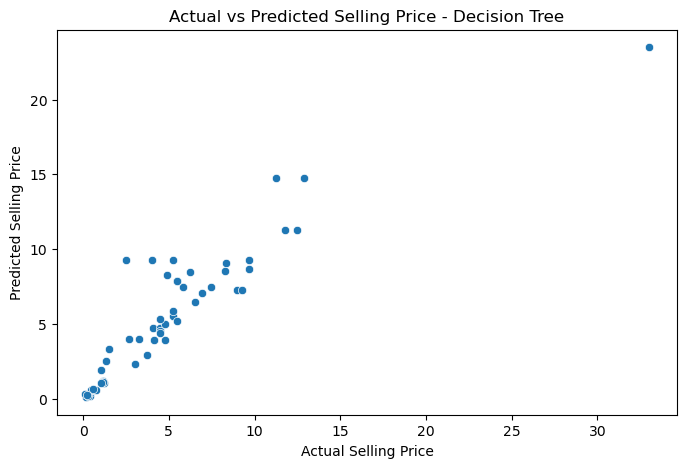

In [52]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=final_predictions)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price - Decision Tree")
plt.show()

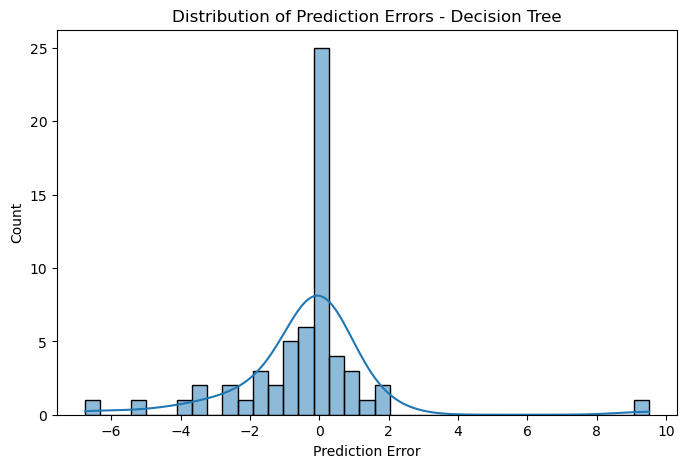

In [53]:
errors = y_test - final_predictions

plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True)
plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors - Decision Tree")
plt.show()

In [54]:
print("Final Selected Model: Decision Tree Regressor")
print(f"MAE: {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R2 Score: {dt_r2:.2f}")

Final Selected Model: Decision Tree Regressor
MAE: 1.07
RMSE: 2.03
R2 Score: 0.84


## Conclusion

In this project, a machine learning regression model was built to predict car selling prices based on features such as present price, kilometers driven, fuel type, transmission, owner count, and car age.

Several regression models were trained and evaluated, including Linear Regression, Random Forest Regressor, and Decision Tree Regressor. Based on the evaluation metrics, the Decision Tree Regressor achieved the best performance with the lowest MAE and RMSE and the highest R2 score.

The final selected model was Decision Tree Regressor, which achieved an R2 score of 0.84. This means the model was able to explain about 84% of the variation in car selling prices.